In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz, plot_tree

sns.set()

# Árboles de decisión
## Árboles de clasificación
**Aprendizaje de Máquina - CEIA - FIUBA**

Para practicar el modelo de árbol de clasificación vamos a usar el dataset **Pima Indians Diabetes**, el mismo con el que trabajamos en las clases 2 (k-NN e hiper-parámetros) y 3 (SVM). Contiene datos médicos de 768 mujeres de la etnia Pima (mayores de 21 años) y el objetivo es predecir si desarrollan diabetes (`diabetes = 1`) o no (`diabetes = 0`).

Elegimos este dataset porque ya tenemos entrenados varios modelos sobre él con el **mismo split**, lo que nos permite comparar el árbol de clasificación contra todo lo anterior (baseline, k-NN, regresión logística y SVC).

> Una ventaja de los árboles es que **no nos afecta el tipo ni la escala de las variables**: no hace falta escalar ni imputar. En este dataset varias columnas (glucosa, insulina, imc, etc.) tienen ceros que en realidad son datos no medidos; los mantenemos tal cual, sin imputar, para no alterar el dataset original.

In [2]:
# Cargamos el dataset
df_pima = pd.read_csv("datasets/pima_diabetes.csv")

In [3]:
df_pima.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   embarazos         768 non-null    int64  
 1   glucosa           768 non-null    int64  
 2   presion_arterial  768 non-null    int64  
 3   grosor_piel       768 non-null    int64  
 4   insulina          768 non-null    int64  
 5   imc               768 non-null    float64
 6   funcion_pedigri   768 non-null    float64
 7   edad              768 non-null    int64  
 8   diabetes          768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df_pima.describe()

,embarazos,glucosa,presion_arterial,grosor_piel,insulina,imc,funcion_pedigri,edad,diabetes
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Veamos la distribución de la variable objetivo.

In [5]:
df_pima.diabetes.value_counts()

diabetes
0    500
1    268
Name: count, dtype: int64

In [6]:
df_pima.head()

,embarazos,glucosa,presion_arterial,grosor_piel,insulina,imc,funcion_pedigri,edad,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Las clases están moderadamente desbalanceadas (aproximadamente 65% / 35%), por lo que la exactitud (*accuracy*) puede ser engañosa. Como en la clase 3, vamos a usar el **F1-Score** como métrica principal de evaluación.

---
Trabajemos en el modelo. Para este caso vamos a usar todos los atributos como predictores.

In [7]:
X = df_pima.drop(columns='diabetes')
y = df_pima['diabetes']

Separamos en entrenamiento y testeo usando el **mismo split** que la notebook de SVC de la clase 3 (estratificado por `y`, `test_size=0.25`, `random_state=0`), para poder comparar de forma directa.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
    random_state=0, stratify=y)

Ahora aplicamos el modelo. Primero llamamos al [árbol de clasificación](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) sin restricciones, para que crezca hasta el final.

In [9]:
# Creamos el arbol
classification = DecisionTreeClassifier(criterion='entropy', splitter='best',
                                        max_depth=None, min_samples_split=2,
                                        min_samples_leaf=1, random_state=42)
# Y entrenamos
classification.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

In [10]:
classification.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'entropy',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

Podemos exportar el árbol para entender qué hizo usando [`export_graphviz`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.export_graphviz.html) (el `.dot` se puede visualizar en [webgraphviz](http://www.webgraphviz.com/?tab=map)):

In [11]:
export_graphviz(classification, out_file="arbol_clasificacion.dot",
                feature_names=X.columns,
                class_names=["No diabetes", "Diabetes"],
                rounded=True,
                filled=True)

Midamos cómo performa este modelo usando el F1-score, en entrenamiento y testeo:

In [12]:
y_pred_train = classification.predict(X_train)
y_pred = classification.predict(X_test)

f1_train = f1_score(y_train, y_pred_train)
f1 = f1_score(y_test, y_pred)

print(f"F1-score de entrenamiento fue: {f1_train}")
print(f"F1-score de testeo fue: {f1}")
print(f"Profundidad del árbol: {classification.get_depth()} | " 
    f"hojas: {classification.get_n_leaves()}")

F1-score de entrenamiento fue: 1.0
F1-score de testeo fue: 0.6074074074074074
Profundidad del árbol: 16 | hojas: 109


El F1 de entrenamiento es **1.0**: el árbol se memoriza el training (sobreajuste), y en testeo cae fuerte. Como con la regresión, necesitamos controlar la complejidad del árbol.

Esta vez, en lugar de podar con `ccp_alpha`, vamos a hacer una **búsqueda de hiper-parámetros** con [Optuna](https://optuna.org/), optimizando el F1 promedio por validación cruzada de 5 folds. Buscamos sobre:

- `max_depth`, `min_samples_split`, `min_samples_leaf` — controlan la complejidad del árbol. Acotamos `max_depth` a un rango chico (**2–15**): probamos rangos más amplios y el óptimo nunca aparecía ahí arriba (la regularización real la hacen los `min_samples_*`), así que ampliarlo sólo agranda la búsqueda sin aportar.
- `criterion` — `gini` vs `entropy`.
- `class_weight` — acá está la clave. Como las clases están **desbalanceadas** y evaluamos con F1, dejamos que Optuna decida si conviene pesar más a la clase minoritaria (`'balanced'`) o no (`None`). Es el hiper-parámetro que más mueve la aguja en este problema.

  ¿Cómo lo aplica el árbol? Le asigna a cada muestra un **peso inversamente proporcional a la frecuencia de su clase** (con `'balanced'`, $w_c = \frac{n}{K \cdot n_c}$, donde $n$ es el total de muestras, $K$ la cantidad de clases y $n_c$ las muestras de la clase $c$). Esos pesos entran en dos lugares: al calcular la **impureza** (gini/entropía) de cada división se usan los conteos *ponderados*, así que separar bien a la minoría "vale" más y el árbol prefiere cortes que la aíslen; y en cada **hoja** la clase predicha sale de la mayoría *ponderada*, no de la simple. El efecto neto es como bajar el umbral de decisión hacia la clase positiva: el árbol se vuelve más sensible a la diabetes (más recall) a costa de más falsos positivos (menos precisión).

In [13]:
import optuna


def objective(trial):
    max_depth = trial.suggest_int("max_depth", 2, 15)
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy"])
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])

    classifier = DecisionTreeClassifier(criterion=criterion, splitter='best',
                                        max_depth=max_depth,
                                        min_samples_split=min_samples_split,
                                        min_samples_leaf=min_samples_leaf,
                                        class_weight=class_weight,
                                        random_state=42)

    # Validación cruzada
    score = cross_val_score(classifier, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
    return score.mean()

In [14]:
def champion_callback(study, frozen_trial):
    """Mostramos menos información, sino es demasiado verboso"""
    winner = study.user_attrs.get("winner", None)
    if study.best_value and winner != study.best_value:
        study.set_user_attr("winner", study.best_value)
        if winner:
            improvement_percent = (abs(winner - study.best_value) / study.best_value)
            improvement_percent *= 100
            print(
                f"Trial {frozen_trial.number} achieved value: {frozen_trial.value} "
                f"with {improvement_percent: .4f}% improvement"
            )
        else:
            print(f"Initial trial {frozen_trial.number} achieved "
                  f"value: {frozen_trial.value}")

In [15]:
# Creamos un estudio de Optuna. Fijamos la semilla del sampler para que el
# resultado sea reproducible. Optuna es verboso, dejamos solo logs de error.
optuna.logging.set_verbosity(optuna.logging.ERROR)

study = optuna.create_study(direction="maximize",
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=500, callbacks=[champion_callback])

Initial trial 0 achieved value: 0.6113807169886308
Trial 1 achieved value: 0.6212089676737309 with  1.5821% improvement
Trial 2 achieved value: 0.6470143278353367 with  3.9884% improvement
Trial 7 achieved value: 0.6701634170602714 with  3.4542% improvement
Trial 25 achieved value: 0.6709606747270171 with  0.1188% improvement
Trial 45 achieved value: 0.6721899891478209 with  0.1829% improvement
Trial 67 achieved value: 0.6745757881942919 with  0.3537% improvement
Trial 70 achieved value: 0.677533414543988 with  0.4365% improvement


In [16]:
# Mejores hiperparámetros encontrados
best_params = study.best_params
best_params

{'max_depth': 4,
 'criterion': 'gini',
 'min_samples_split': 16,
 'min_samples_leaf': 13,
 'class_weight': 'balanced'}

In [17]:
# Creamos el arbol con los mejores hiperparámetros y lo entrenamos
classification = DecisionTreeClassifier(**best_params, random_state=42)
classification.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",16
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",13
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are c

In [18]:
y_pred = classification.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"La exactitud de clasificación es: {accuracy}")
print(f"F1-score de testeo fue: {f1}")
print(f"Precisión de testeo fue: {precision}")
print(f"Recall de testeo fue: {recall}")

La exactitud de clasificación es: 0.7447916666666666
F1-score de testeo fue: 0.6956521739130435
Precisión de testeo fue: 0.5957446808510638
Recall de testeo fue: 0.835820895522388


El árbol optimizado quedó **mucho más chico y general** que el original: elige `class_weight='balanced'` y una profundidad baja (apenas unas pocas hojas). Lo exportamos y lo visualizamos:

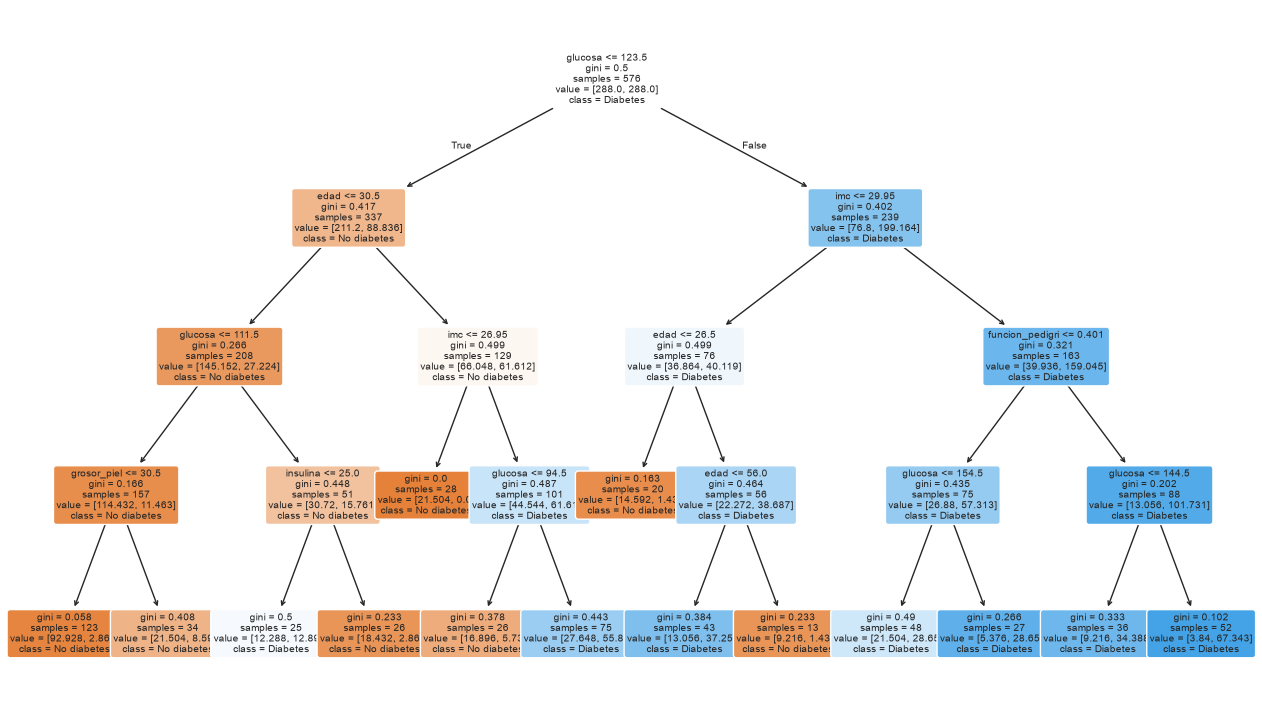

In [19]:
export_graphviz(classification, out_file="arbol_clasificacion_optuna.dot",
                feature_names=X.columns,
                class_names=["No diabetes", "Diabetes"],
                rounded=True,
                filled=True)

fig, ax = plt.subplots(figsize=(16, 9))
plot_tree(classification, filled=True, feature_names=list(X.columns),
          class_names=["No diabetes", "Diabetes"], rounded=True, fontsize=7, ax=ax);

Veamos la matriz de confusión sobre el set de testeo:

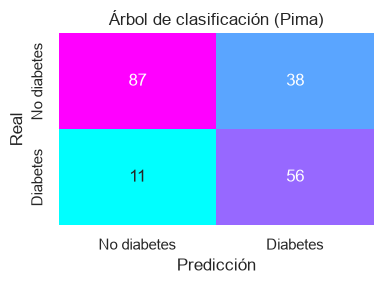

In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=classification.classes_)
etiquetas = ["No diabetes", "Diabetes"]

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="cool", cbar=False, ax=ax,
            xticklabels=etiquetas, yticklabels=etiquetas)
ax.set_title("Árbol de clasificación (Pima)")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

Y la curva ROC:

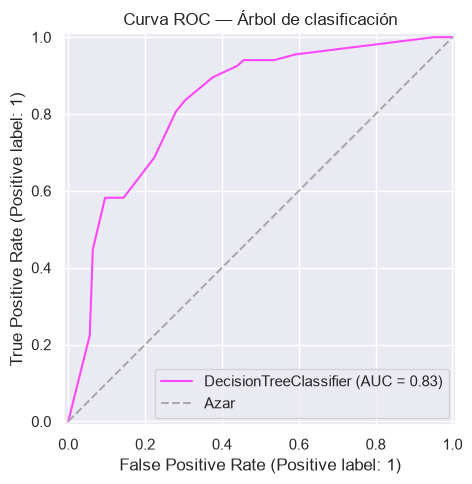

In [21]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(5, 5))
RocCurveDisplay.from_estimator(classification, X_test, y_test, ax=ax,
                               curve_kwargs={"color": "#ff48fd"})
ax.plot([0, 1], [0, 1], linestyle="--", color="#aaaaaa", label="Azar")
ax.set_title("Curva ROC — Árbol de clasificación")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

---
## Comparativa final entre todos los casos

A lo largo de las **clases 2, 3 y 4** entrenamos varios modelos sobre el mismo dataset (Pima Indians Diabetes) y con el **mismo split** (`test_size=0.25`, `random_state=0`, `stratify=y`), lo que nos permite compararlos de forma directa sobre el mismo conjunto de testeo:

- **Baseline (umbral de glucosa)** — regla heurística derivada del EDA: `glucosa` es el predictor más discriminativo. No requiere entrenamiento y funciona como piso de referencia.
- **Mejor KNN (Optuna)** — el mejor clasificador k-NN encontrado en la clase 2.
- **Regresión Logística (balanced)** — modelo lineal clásico (`C=1`, `class_weight='balanced'`) de la notebook auxiliar de la clase 2.
- **SVC (balanced)** — el mejor SVM encontrado en la clase 3 (kernel lineal con `class_weight='balanced'`), reproducido acá.
- **Árbol de clasificación** — el modelo que desarrollamos en este notebook, con `class_weight='balanced'` para compensar el desbalance de clases.

Las métricas son **F1-score**, **exactitud balanceada**, **precisión** y **recall**.

> **Nota:** todos los modelos que lo permiten (árbol, logística y SVC) usan `class_weight='balanced'`, así que la comparación es justa en el manejo del desbalance. El **baseline** y el **KNN** no tienen ese mecanismo disponible.

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# El árbol ya está entrenado sobre X_train/X_test sin escalar (y_pred de arriba).
# El KNN, la logística y el SVC necesitan escalado -> los metemos en Pipelines.

# --- 1) Baseline: umbral de glucosa (predictor más discriminativo según el EDA) ---
glucosa_sin = df_pima.loc[df_pima["diabetes"] == 0, "glucosa"]
glucosa_con = df_pima.loc[df_pima["diabetes"] == 1, "glucosa"]
umbral_glucosa = (glucosa_sin.median() + glucosa_con.median()) / 2
y_pred_baseline = (X_test["glucosa"] > umbral_glucosa).astype(int).values

# --- 2) Mejor KNN de la clase 2 (encontrado con Optuna) ---
best_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier(n_neighbors=3, weights='uniform',
                                        p=3.758948544078171))
])
best_knn.fit(X_train, y_train)
y_pred_knn = best_knn.predict(X_test)

# --- 3) Regresión logística (notebook auxiliar de la clase 2) ---
best_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(C=1, class_weight='balanced', solver='liblinear',
                                 max_iter=5000))
])
best_logreg.fit(X_train, y_train)
y_pred_logreg = best_logreg.predict(X_test)

# --- 4) Mejor SVC de la clase 3 (reproducimos la búsqueda de grilla) ---
best_svc = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', GridSearchCV(SVC(),
        [{"C": [0.01, 0.1, 1, 5, 10, 100], "kernel": ["linear"],
          "class_weight": [None, "balanced"]},
         {"C": [0.01, 0.1, 1, 5, 10, 100], "gamma": [0.1, 0.5, 1, 2, 10, 100],
          "kernel": ["rbf"], "class_weight": [None, "balanced"]},
         {"C": [0.01, 0.1, 1, 5, 10, 100], "degree": [2, 3, 4, 5, 6],
          "kernel": ["poly"], "class_weight": [None, "balanced"]}],
        cv=5, scoring='f1'))
])
best_svc.fit(X_train, y_train)
y_pred_svc = best_svc.predict(X_test)

# --- 5) Árbol de clasificación de este notebook ---
y_pred_tree = y_pred

modelos = ["Baseline (umbral glucosa)", "Mejor KNN (Optuna)",
           "Regresión Logística", "SVC (balanced)", "Árbol de clasificación"]
preds = [y_pred_baseline, y_pred_knn, y_pred_logreg, y_pred_svc, y_pred_tree]

df_cmp = pd.DataFrame({
    "F1-score": [f1_score(y_test, yp) for yp in preds],
    "Exactitud balanceada": [balanced_accuracy_score(y_test, yp) for yp in preds],
    "Precisión": [precision_score(y_test, yp, zero_division=0) for yp in preds],
    "Recall": [recall_score(y_test, yp, zero_division=0) for yp in preds],
}, index=pd.Index(modelos))

df_cmp.round(4)

,F1-score,Exactitud balanceada,Precisión,Recall
Baseline (umbral glucosa),0.6533,0.7297,0.5904,0.7313
Mejor KNN (Optuna),0.6230,0.7156,0.6909,0.5672
Regresión Logística,0.7273,0.7921,0.6842,0.7761
SVC (balanced),0.7092,0.7771,0.6757,0.7463
Árbol de clasificación,0.6957,0.7659,0.5957,0.8358


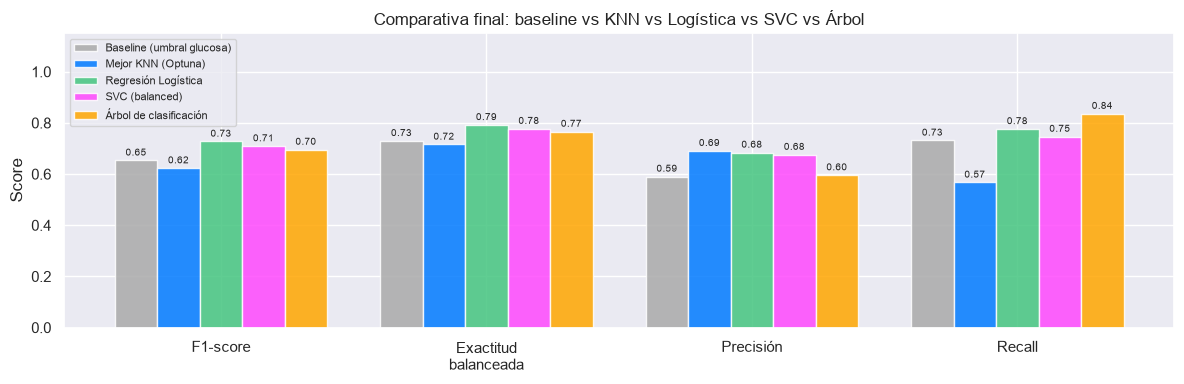

In [23]:
colores = ["#aaaaaa", "#007aff", "#44c57f", "#ff48fd", "#ffa600"]
metric_labels = ["F1-score", "Exactitud\nbalanceada", "Precisión", "Recall"]
x = np.arange(len(metric_labels))
n = len(modelos)
width = 0.8 / n

fig, ax = plt.subplots(figsize=(12, 4))
for i, (modelo, color) in enumerate(zip(modelos, colores)):
    bars = ax.bar(x + (i - (n - 1) / 2) * width, df_cmp.iloc[i], width,
                  label=modelo, color=color, alpha=0.85)
    ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=7)

ax.set_ylim(0, 1.15)
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylabel("Score")
ax.set_title("Comparativa final: baseline vs KNN vs Logística vs SVC vs Árbol")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Observaciones

- Sobre este dataset, la **regresión logística** es la que mejor **F1-score (≈ 0.73)** y **exactitud balanceada (≈ 0.79)** consigue, seguida de cerca por el **SVC (≈ 0.71)**. El **árbol de clasificación** queda tercero (**≈ 0.70**): en un problema chico y con señal esencialmente lineal como Pima, la flexibilidad extra de un árbol no le gana a un buen modelo lineal.
- Donde el árbol **sí** se destaca es en **recall (≈ 0.84, el más alto de todos)**: es el modelo que más pacientes con diabetes detecta, a costa de la precisión más baja (≈ 0.60). Si el objetivo del *screening* es no dejar pasar casos positivos, es una opción muy atractiva y, además, totalmente interpretable (apenas 14 hojas y profundidad 4).
- Los tres modelos que lo permiten (árbol, logística y SVC) usan `class_weight='balanced'` para compensar el desbalance. El **baseline de glucosa** y el **KNN**, que no cuentan con ese mecanismo, quedan por debajo: buena parte de la ventaja de los primeros viene, justamente, de tratar el desbalance de clases.

----
Para terminar, veamos un modelo de **dos dimensiones** para entender cómo son las regiones de decisión de un árbol. Usamos las dos variables más informativas del EDA: `glucosa` e `imc`.

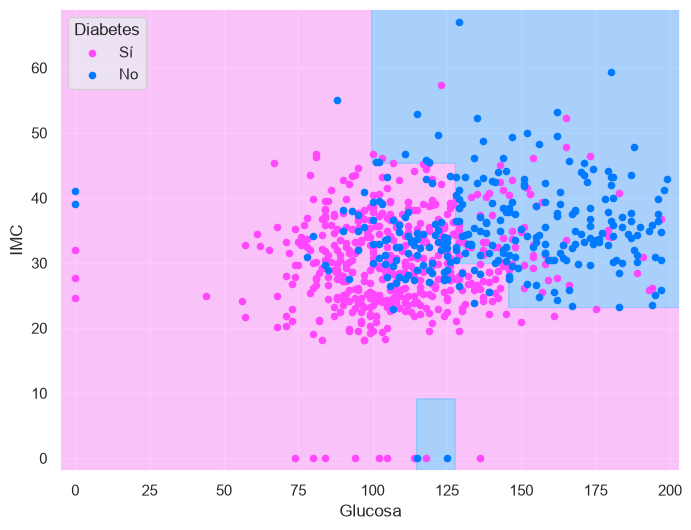

In [24]:
from auxiliary import plot_boundary

X_2d = df_pima.loc[:, ["glucosa", "imc"]].values
y_2d = df_pima["diabetes"].values

# Un árbol poco profundo para ver regiones interpretables
arbol_2d = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
arbol_2d.fit(X_2d, y_2d)

plot_boundary(X_2d, y_2d, arbol_2d,
              step_x=(0.5, 0.25),
              max_x=(5, 2),
              min_x=(-5, -2),
              colormap_frontier=('#ffb7fe', '#93c7ff'),
              colormap_points=('#ff48fd', '#007aff'),
              figsize=(8, 6),
              label_point=("Sí", "No"),
              legend=True,
              legend_title="Diabetes",
              labels_axis=("Glucosa", "IMC"),
              point_size=20);

Se ve claramente la característica distintiva de los árboles: las fronteras de decisión son **rectángulos alineados a los ejes** (cada división es un umbral sobre una sola variable). Esto los hace muy interpretables, pero también explica por qué un modelo con frontera curva como el SVC puede capturar mejor ciertas relaciones.